In [1]:
import pandas as pd

df = pd.read_csv("../data/AB_NYC_2019.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nSample prices:", df["price"].head(10))

Shape: (48895, 16)
Columns: ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Sample prices: 0    149
1    225
2    150
3     89
4     80
5    200
6     60
7     79
8     79
9    150
Name: price, dtype: int64


In [2]:
print("Missing values:")
print(df.isnull().sum())

print("\nPrice stats:")
print(df["price"].describe())

Missing values:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Price stats:
count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


In [3]:
# Remove listings with zero price
df = df[df["price"] > 0].copy()

# Remove extreme outliers (above $1000)
df = df[df["price"] <= 1000].copy()

# Remove extreme minimum nights
df = df[df["minimum_nights"] <= 365].copy()

# Fill missing reviews_per_month with 0
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

# Drop rows with missing name
df = df.dropna(subset=["name"])

print("Shape after cleaning:", df.shape)
print("\nPrice stats after cleaning:")
print(df["price"].describe().round(2))

Shape after cleaning: (48616, 16)

Price stats after cleaning:
count    48616.00
mean       141.32
std        116.75
min         10.00
25%         69.00
50%        105.00
75%        175.00
max       1000.00
Name: price, dtype: float64


In [4]:
import sqlite3

conn = sqlite3.connect("../data/airbnb_nyc.db")

df.to_sql("listings", conn, if_exists="replace", index=False)

print("Database created successfully!")
print(f"Total rows loaded: {pd.read_sql('SELECT COUNT(*) as count FROM listings', conn)['count'][0]}")

Database created successfully!
Total rows loaded: 48616


In [5]:
query1 = """
SELECT 
    neighbourhood_group,
    COUNT(*) as total_listings,
    ROUND(AVG(price), 2) as avg_price,
    ROUND(MIN(price), 2) as min_price,
    ROUND(MAX(price), 2) as max_price
FROM listings
GROUP BY neighbourhood_group
ORDER BY avg_price DESC
"""

result1 = pd.read_sql(query1, conn)
print("Average price by borough:")
print(result1)

Average price by borough:
  neighbourhood_group  total_listings  avg_price  min_price  max_price
0           Manhattan           21474     178.95       10.0     1000.0
1            Brooklyn           20029     117.88       10.0     1000.0
2       Staten Island             371      98.58       13.0     1000.0
3              Queens            5654      94.98       10.0     1000.0
4               Bronx            1088      85.32       10.0     1000.0


In [6]:
query2 = """
SELECT 
    room_type,
    COUNT(*) as total_listings,
    ROUND(AVG(price), 2) as avg_price
FROM listings
GROUP BY room_type
ORDER BY avg_price DESC
"""

result2 = pd.read_sql(query2, conn)
print("Average price by room type:")
print(result2)

Average price by room type:
         room_type  total_listings  avg_price
0  Entire home/apt           25201     194.62
1     Private room           22261      84.80
2      Shared room            1154      67.64


In [7]:
query3 = """
SELECT 
    neighbourhood,
    neighbourhood_group,
    COUNT(*) as total_listings,
    ROUND(AVG(price), 2) as avg_price
FROM listings
GROUP BY neighbourhood
HAVING total_listings >= 10
ORDER BY avg_price DESC
LIMIT 10
"""

result3 = pd.read_sql(query3, conn)
print("Top 10 most expensive neighbourhoods:")
print(result3)

Top 10 most expensive neighbourhoods:
        neighbourhood neighbourhood_group  total_listings  avg_price
0             Tribeca           Manhattan             165     330.39
1                NoHo           Manhattan              77     276.25
2   Flatiron District           Manhattan              76     275.05
3             Midtown           Manhattan            1525     265.70
4                SoHo           Manhattan             350     254.34
5        West Village           Manhattan             754     239.49
6           Riverdale               Bronx              10     236.30
7    Theater District           Manhattan             285     228.89
8             Chelsea           Manhattan            1100     222.73
9  Financial District           Manhattan             742     219.76


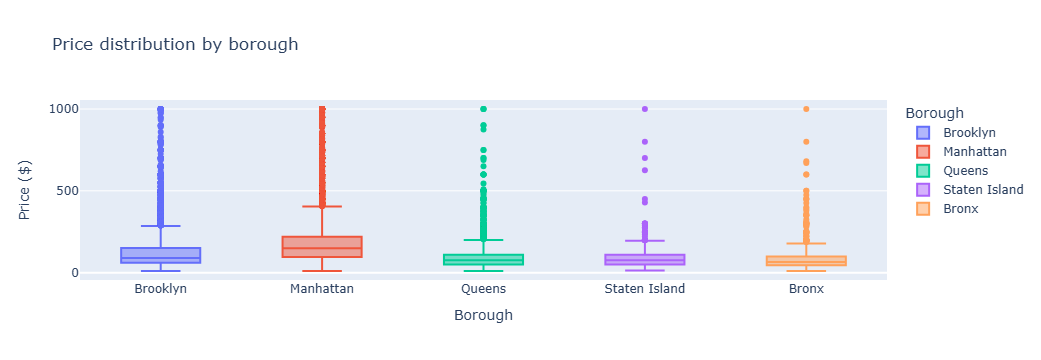

In [8]:
import plotly.express as px

fig = px.box(
    df,
    x="neighbourhood_group",
    y="price",
    color="neighbourhood_group",
    title="Price distribution by borough",
    labels={"neighbourhood_group": "Borough", "price": "Price ($)"}
)
fig.show()

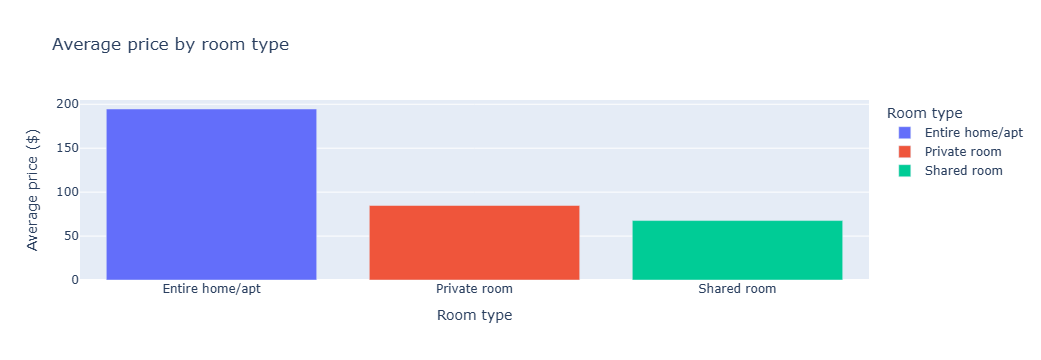

In [9]:
fig = px.bar(
    result2,
    x="room_type",
    y="avg_price",
    color="room_type",
    title="Average price by room type",
    labels={"room_type": "Room type", "avg_price": "Average price ($)"}
)
fig.show()

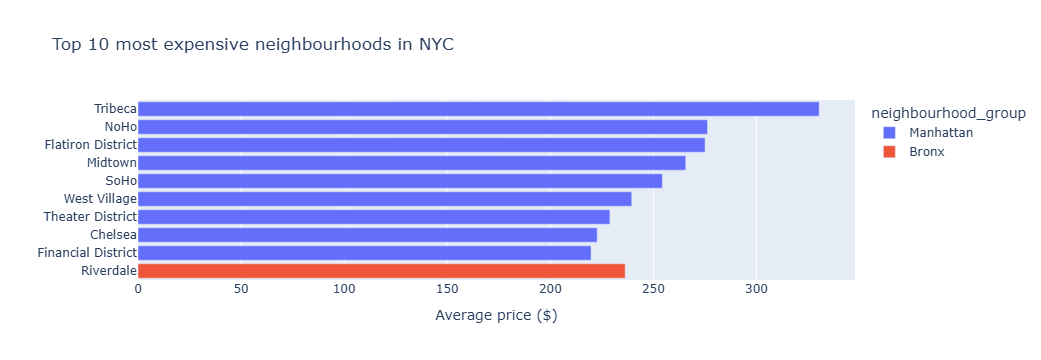

In [10]:
fig = px.bar(
    result3,
    x="avg_price",
    y="neighbourhood",
    orientation="h",
    color="neighbourhood_group",
    title="Top 10 most expensive neighbourhoods in NYC",
    labels={"avg_price": "Average price ($)", "neighbourhood": ""}
)
fig.update_layout(yaxis=dict(autorange="reversed"))
fig.show()

C:\Users\Trilo\AppData\Local\Temp\ipykernel_38744\556130718.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


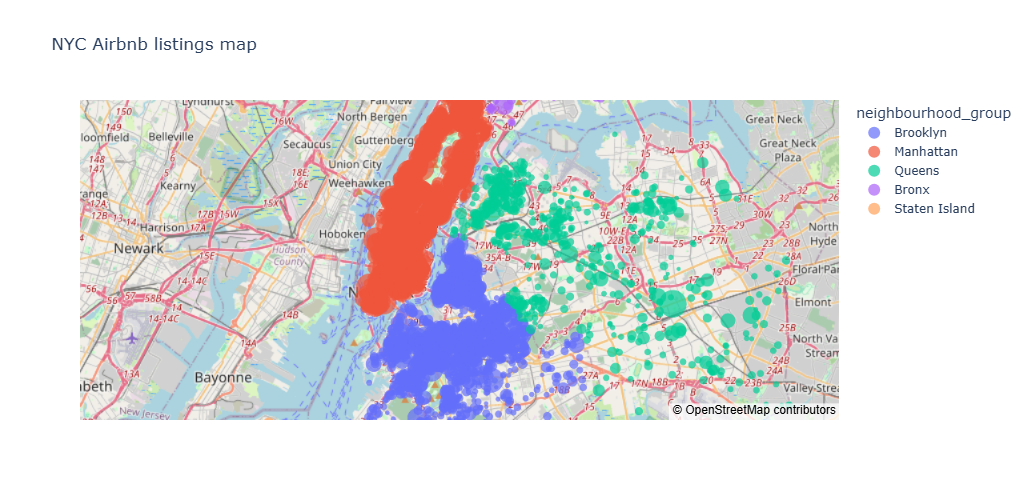

In [11]:
fig = px.scatter_mapbox(
    df.sample(5000),
    lat="latitude",
    lon="longitude",
    color="neighbourhood_group",
    size="price",
    hover_name="name",
    hover_data={"price": True, "room_type": True},
    zoom=10,
    height=500,
    title="NYC Airbnb listings map"
)
fig.update_layout(mapbox_style="open-street-map")
fig.show()

In [12]:
from sklearn.preprocessing import LabelEncoder

model_df = df[[
    "neighbourhood_group",
    "neighbourhood",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "price"
]].copy()

le_borough = LabelEncoder()
le_neighbourhood = LabelEncoder()
le_room = LabelEncoder()

model_df["neighbourhood_group_enc"] = le_borough.fit_transform(model_df["neighbourhood_group"])
model_df["neighbourhood_enc"] = le_neighbourhood.fit_transform(model_df["neighbourhood"])
model_df["room_type_enc"] = le_room.fit_transform(model_df["room_type"])

print("Features prepared:")
print(model_df.head(3))

Features prepared:
  neighbourhood_group neighbourhood        room_type  minimum_nights  \
0            Brooklyn    Kensington     Private room               1   
1           Manhattan       Midtown  Entire home/apt               1   
2           Manhattan        Harlem     Private room               3   

   number_of_reviews  reviews_per_month  calculated_host_listings_count  \
0                  9               0.21                               6   
1                 45               0.38                               2   
2                  0               0.00                               1   

   availability_365  price  neighbourhood_group_enc  neighbourhood_enc  \
0               365    149                        1                108   
1               355    225                        2                127   
2               365    150                        2                 94   

   room_type_enc  
0              1  
1              0  
2              1  


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

features = [
    "neighbourhood_group_enc",
    "neighbourhood_enc",
    "room_type_enc",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

X = model_df[features]
y = model_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ${mae:.2f}")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error: $51.86
R² Score: 0.414


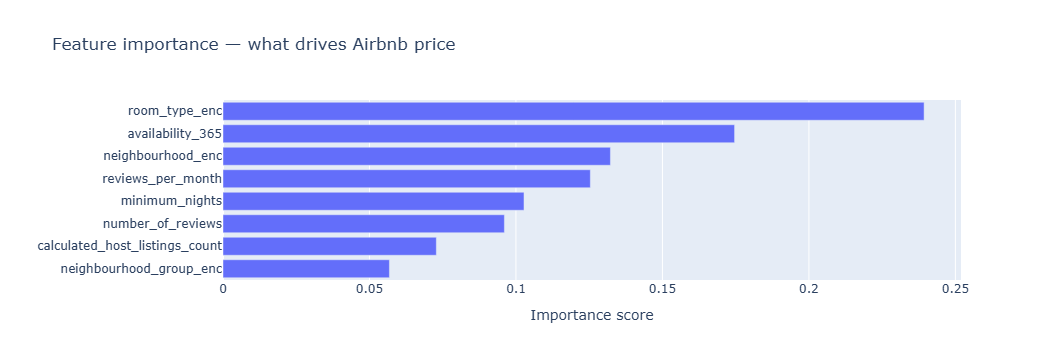

In [14]:
importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=True)

fig = px.bar(
    importance_df,
    x="importance",
    y="feature",
    orientation="h",
    title="Feature importance — what drives Airbnb price",
    labels={"importance": "Importance score", "feature": ""}
)
fig.show()

In [15]:
import joblib
import os

os.makedirs("../output", exist_ok=True)

joblib.dump(model, "../output/price_model.pkl")
joblib.dump(le_borough, "../output/le_borough.pkl")
joblib.dump(le_neighbourhood, "../output/le_neighbourhood.pkl")
joblib.dump(le_room, "../output/le_room.pkl")

print("Model and encoders saved successfully!")

Model and encoders saved successfully!


In [16]:
df.to_csv("../data/airbnb_clean.csv", index=False)
result1.to_csv("../data/borough_stats.csv", index=False)
result2.to_csv("../data/roomtype_stats.csv", index=False)
result3.to_csv("../data/neighbourhood_stats.csv", index=False)

print("All files saved!")

All files saved!


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import joblib
import os

df = pd.read_csv("../data/airbnb_clean.csv")

le_borough = LabelEncoder()
le_neighbourhood = LabelEncoder()
le_room = LabelEncoder()

df["neighbourhood_group_enc"] = le_borough.fit_transform(df["neighbourhood_group"])
df["neighbourhood_enc"] = le_neighbourhood.fit_transform(df["neighbourhood"])
df["room_type_enc"] = le_room.fit_transform(df["room_type"])

features = [
    "neighbourhood_group_enc",
    "neighbourhood_enc",
    "room_type_enc",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

X = df[features]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

small_model = RandomForestRegressor(
    n_estimators=10,
    max_depth=10,
    random_state=42
)
small_model.fit(X_train, y_train)

y_pred = small_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE: ${mae:.2f}")
print(f"R²: {r2:.3f}")

joblib.dump(small_model, "../output/price_model.pkl")
joblib.dump(le_borough, "../output/le_borough.pkl")
joblib.dump(le_neighbourhood, "../output/le_neighbourhood.pkl")
joblib.dump(le_room, "../output/le_room.pkl")

size_mb = os.path.getsize("../output/price_model.pkl") / 1e6
print(f"Model size: {size_mb:.1f} MB")


MAE: $50.62
R²: 0.422
Model size: 1.1 MB
